<a href="https://colab.research.google.com/github/natvl99/datasets/blob/main/AI%26Social_media_impact_students_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI & Social Media Impact: Students Health

In [1]:
import pandas as pd

# 1. Φορτώνουμε το dataset
df = pd.read_csv('/AI_SocialMedia_Student_Dataset.csv')

# 2. Εμφανίζουμε τις πρώτες 5 γραμμές για τσεκ
df.head()

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04


In [2]:
# 3. Βλέπουμε γενικές πληροφορίες
print("--- Γενικές Πληροφορίες (df.info) ---")
df.info()

print("\n")

# 4. Βλέπουμε τον αριθμό των κενών τιμών (Missing Values) ανά στήλη
print("Σύνολο Κενών Τιμών ανά Στήλη")
print(df.isnull().sum())

--- Γενικές Πληροφορίες (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 16000 non-null  object 
 1   Age                        16000 non-null  int64  
 2   Gender                     16000 non-null  object 
 3   Education_Level            16000 non-null  object 
 4   Daily_Social_Media_Hours   16000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours  16000 non-null  float64
 6   Sleep_Hours                16000 non-null  float64
 7   Physical_Activity_Hours    16000 non-null  float64
 8   Mental_Health_Score        16000 non-null  float64
 9   Physical_Health_Score      16000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 1.2+ MB


Σύνολο Κενών Τιμών ανά Στήλη
Student_ID                   0
Age                          0
Gender                    

In [3]:
# 5. Έλεγχος για διπλότυπες εγγραφές
print("Διπλότυπες εγγραφές:", df.duplicated().sum())

# 6. Βασικά στατιστικά για να εντοπίσουμε τυχόν ακραίες τιμές (outliers)
df.describe()

Διπλότυπες εγγραφές: 0


,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
count,16000.00000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,19.03875,4.541791,2.590624,6.545371,1.248359,72.493193,88.020465
std,3.76527,2.403044,1.679376,1.270515,1.038632,9.244818,9.691037
min,13.00000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000
25%,16.00000,2.840000,1.310000,5.680000,0.310000,66.760000,81.517500
50%,19.00000,4.500000,2.520000,6.540000,1.130000,73.750000,89.455000
75%,22.00000,6.180000,3.750000,7.410000,1.960000,79.550000,97.170000
max,25.00000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000


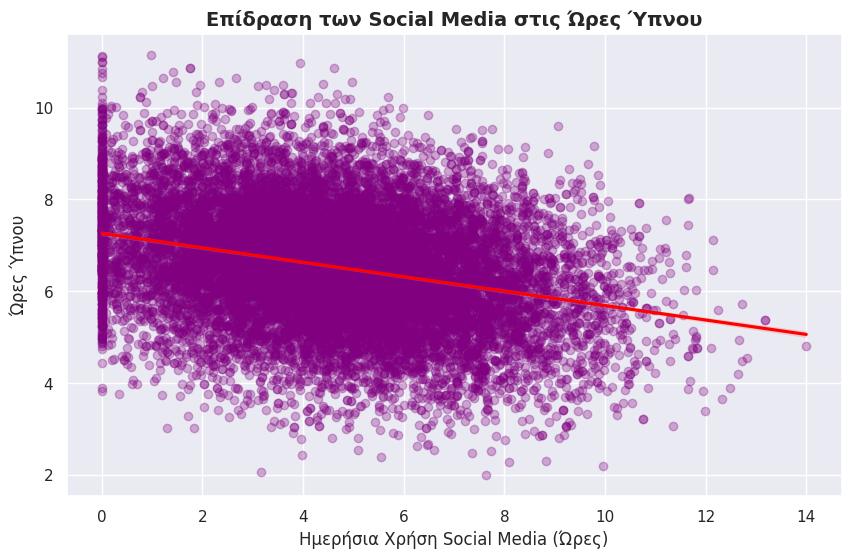

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Ρυθμίζουμε την αισθητική του γραφήματος
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

# 8. Δημιουργούμε scatter plot με γραμμή τάσης (regression line)
sns.regplot(data=df, x="Daily_Social_Media_Hours", y="Sleep_Hours",
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red'})

plt.title("Επίδραση των Social Media στις Ώρες Ύπνου", fontsize=14, fontweight='bold')
plt.xlabel("Ημερήσια Χρήση Social Media (Ώρες)", fontsize=12)
plt.ylabel("Ώρες Ύπνου", fontsize=12)
plt.show()

💡**Σχολιασμός**:
Εντοπίζεται σαφής αρνητική συσχέτιση μεταξύ του χρόνου οθόνης (social media) και της διάρκειας του ύπνου. Όσο περισσότερο χρόνο καταναλώνουν οι μαθητές στα κοινωνικά δίκτυα τόσο λιγότερες ώρες ύπνου συμπληρώνουν.

/tmp/ipykernel_5272/3712611320.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='SM_Usage_Category', y='Mental_Health_Score', palette='magma')


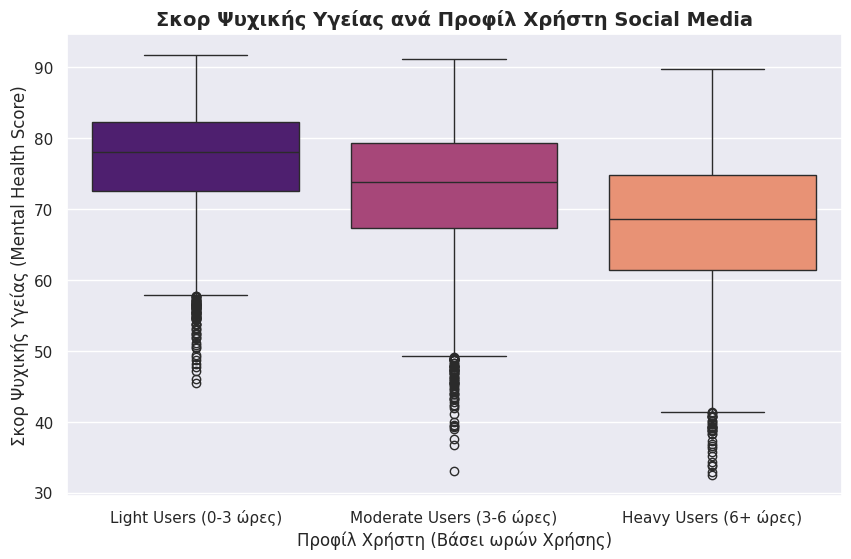

In [6]:
# 9. Τμηματοποίηση (Segmentation) χρηστών
bins = [0, 3, 6, 24]
labels = ['Light Users (0-3 ώρες)', 'Moderate Users (3-6 ώρες)', 'Heavy Users (6+ ώρες)']
df['SM_Usage_Category'] = pd.cut(df['Daily_Social_Media_Hours'], bins=bins, labels=labels, include_lowest=True)

# 10. Οπτικοποίηση με Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='SM_Usage_Category', y='Mental_Health_Score', palette='magma')

plt.title("Σκορ Ψυχικής Υγείας ανά Προφίλ Χρήστη Social Media", fontsize=14, fontweight='bold')
plt.xlabel("Προφίλ Χρήστη (Βάσει ωρών Χρήσης)", fontsize=12)
plt.ylabel("Σκορ Ψυχικής Υγείας (Mental Health Score)", fontsize=12)
plt.show()

💡Insight:
Η ανάλυση των προφίλ αποκαλύπτει μια ισχυρή αρνητική συσχέτιση μεταξύ της παρατεταμένης έκθεσης στα social media και της ψυχικής ευημερίας. Οι "Heavy Users" (6+ ώρες) παρουσιάζουν αισθητά χαμηλότερο διάμεσο σκορ ψυχικής υγείας σε σύγκριση με τους "Light Users".
